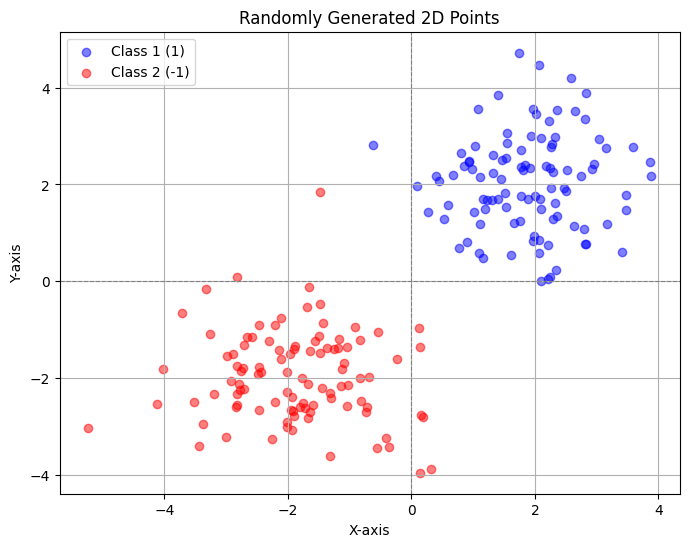

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# 设置随机种子以确保可重复性
np.random.seed(42)

# 生成线性可分的两类数据
# 类别 1 (标记为 1)
X1 = np.random.randn(100, 2) + np.array([2, 2])  # 平移到 (2, 2)
y1 = np.ones(100)

# 类别 2 (标记为 -1)
X2 = np.random.randn(100, 2) + np.array([-2, -2])  # 平移到 (-2, -2)
y2 = -1 * np.ones(100)

# 合并数据
X = np.vstack((X1, X2))
y = np.hstack((y1, y2))

# 可视化数据
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1 (1)', alpha=0.5)
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class 2 (-1)', alpha=0.5)
plt.title('Randomly Generated 2D Points')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axhline(0, color='grey', lw=0.8, ls='--')
plt.axvline(0, color='grey', lw=0.8, ls='--')
plt.grid()
plt.legend()
plt.show()


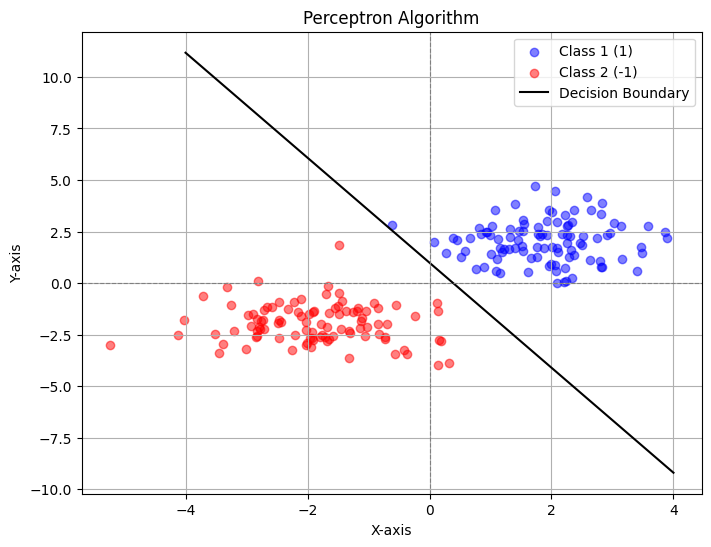

In [21]:
import matplotlib.pyplot as plt

# 增广
X_augmented = np.hstack((np.ones((X.shape[0], 1)), X))

# 感知器算法实现
def perceptron(X, y, max_iter=100):
    alpha = np.zeros(X.shape[1])
    for _ in range(max_iter):
        for i in range(len(y)):
            if y[i] * np.dot(alpha, X[i]) <= 0:  # 更新条件
                alpha += y[i] * X[i]  # 权重更新
    return alpha

# 训练感知器
alpha = perceptron(X_augmented, y)

# 绘制数据点和决策边界
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1 (1)', alpha=0.5)
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class 2 (-1)', alpha=0.5)

# 绘制决策边界
x_vals = np.linspace(-4, 4, 100)
y_vals = -(alpha[1] / alpha[2]) * x_vals - (alpha[0] / alpha[2])
plt.plot(x_vals, y_vals, color='black', label='Decision Boundary')

plt.title('Perceptron Algorithm')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axhline(0, color='grey', lw=0.8, ls='--')
plt.axvline(0, color='grey', lw=0.8, ls='--')
plt.grid()
plt.legend()
plt.show()


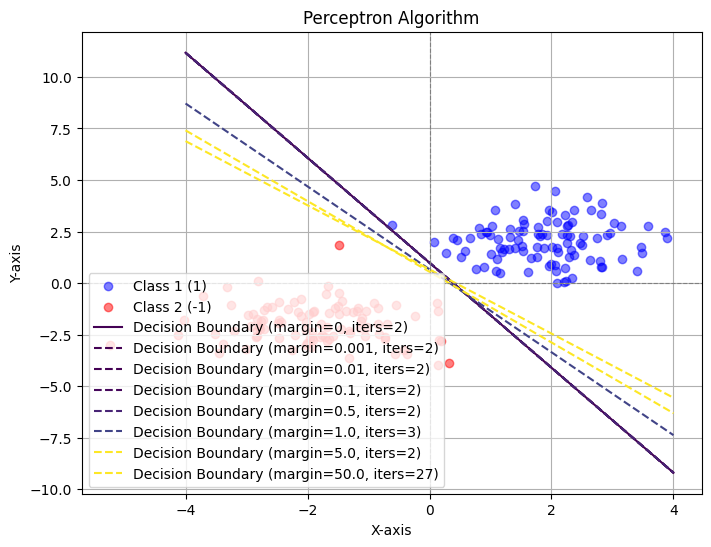

In [23]:
# 增广
X_augmented = np.hstack((np.ones((X.shape[0], 1)), X))

# 感知器算法实现
def perceptron_marign(X, y, max_iter=1000,marign=0):
    alpha = np.zeros(X.shape[1])
    for iters in range(max_iter):
        stop = True
        for i in range(len(y)):
            if y[i] * np.dot(alpha, X[i]) <= marign:  # 更新条件
                alpha += y[i] * X[i]  # 权重更新
                stop = False
        if stop == True:
            return iters, alpha
    return max_iter, alpha



# 绘制数据点和决策边界
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 1, 0], X[y == 1, 1], color='blue', label='Class 1 (1)', alpha=0.5)
plt.scatter(X[y == -1, 0], X[y == -1, 1], color='red', label='Class 2 (-1)', alpha=0.5)

for marign in [0,1e-3, 1e-2, 0.1,0.5, 1.0, 5.0, 50.0]:
    # 训练感知器
    iters, alpha = perceptron_marign(X_augmented, y, marign=marign)
    # 绘制决策边界
    x_vals = np.linspace(-4, 4, 100)
    y_vals = -(alpha[1] / alpha[2]) * x_vals - (alpha[0] / alpha[2])
    plt.plot(x_vals, y_vals, label=f'Decision Boundary (margin={marign}, iters={iters})', linestyle='--' if marign > 0 else '-', color=plt.cm.viridis(marign / 5.0))


plt.title('Perceptron Algorithm')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.axhline(0, color='grey', lw=0.8, ls='--')
plt.axvline(0, color='grey', lw=0.8, ls='--')
plt.grid()
plt.legend()
plt.show()